# Prior Monte Carlo

_The first honest look at what our model predicts — before we fit a single data point._

Prior-based (or "unconstrained") Monte Carlo is a simple but often skipped analysis. Sample many sets of parameters from the prior, run the model forward for each, and collate the results. We do not try to fit the historical data yet, and we do not throw out realisations because they "look wrong". The point is to see the full range of outcomes the model produces across the prior range of the parameters.

That range tells us a lot. It shows whether the model is stable under the parameters we are throwing at it, whether the conditioning data we collected in the [obs & weights notebook](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb) actually sit inside the simulated spread, and — most usefully — whether we even need to history match at all.

### The Current Tutorial

This notebook picks up from the [pstfrom setup](../part1_02_pstfrom_setup/dizon_pstfrom_setup.ipynb) notebook, where the layered prior and the named forecast group were built, and the [obs & weights notebook](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb), where the conditioning species were weighted, the held-back cations set aside, and the synthetic truth chosen. We run the prior ensemble once, look at the simulated spread against the measured data, and then ask the decision question of the prior:

> **How much sulfate will the supplied water carry, and how sure are we?**

The forecast is peak SO₄ at the supply well during the supply period, and the operator sizes treatment capacity to its upper tail — so the payoff of this notebook is the whole *prior forecast distribution*: where it sits and how wide it is. That width is the single most valuable thing a prior MC can tell you, and it is what decides whether history matching is worth the days of compute it costs.

The DSI emulator that does the actual conditioning is built in the next notebook, [dsi basics](../part1_05_dsi_basics/dizon_dsi_basics.ipynb). It trains on the prior ensemble we generate here.

### Admin

The cells below load dependencies and prepare the PEST dataset folder. The control file, layered prior ensemble, conditioning weights and synthetic truth were all built upstream — here we just copy that template into this notebook's own working directory and run it.

A note on cost, because it is the whole point of this curriculum: **the DIZON model takes ~6 min per run on a MacBook** (longer on a workshop laptop). That number governs everything that follows. Just press `shift+enter` to run the cells.

In [1]:
import os
import shutil
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
from pathlib import Path

import sys
import flopy
import pyemu
# make sure we are using the vendored dependencies shipped with this repo
assert "dependencies" in flopy.__file__, "flopy is not the vendored copy - check your environment"
assert "dependencies" in pyemu.__file__, "pyemu is not the vendored copy - check your environment"
sys.path.insert(0, "..")
import herebedragons as hbd

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


We work on a copy of the upstream PEST dataset so re-running this notebook never touches the original. The source folder is the `obs_template` produced by the obs & weights notebook. If it isn't there, run that notebook first.

In [2]:
# this notebook's own working copy of the template
t_d = Path("pst_template")
if t_d.exists():
    shutil.rmtree(t_d)

# the template produced upstream by the obs & weights notebook
org_t_d = Path(os.path.join("..", "part1_03_obs_weights_and_truth", "obs_template"))
if not org_t_d.exists():
    raise Exception(
        "could not find the upstream PEST template - "
        "you need to run the '../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb' notebook first"
    )
shutil.copytree(org_t_d, t_d)

PosixPath('pst_template')

Load the PEST control file as a `Pst` object:

In [3]:
pst = pyemu.Pst(str(t_d / "pest.pst"))

A quick prerequisite check. The obs & weights notebook is where the conditioning species are given non-zero weight (everything after the decision date is weighted to zero) and the held-back cations are switched off. If *every* observation is still weighted, that step hasn't run and the prior MC would condition on the wrong things downstream.

In [4]:
# the obs & weights notebook leaves a strict subset of observations with non-zero weight
if pst.nnz_obs == 0:
    raise Exception(
        "no non-zero-weight observations found - "
        "run the '../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb' notebook first"
    )
print(f"{pst.nnz_obs} of {pst.nobs} observations carry non-zero weight")

26191 of 231725 observations carry non-zero weight


## Setting up the prior Monte Carlo

We use the `pestpp-ies` executable to run the prior ensemble. It may look like we are jumping ahead — `pestpp-ies` is the iterative Ensemble Smoother, the tool we will use for conditioning later — but prior Monte Carlo is built into it. Running an ensemble once is simply `pestpp-ies` with `noptmax = -1`.

Two `pestpp_options` matter here. We point `ies_par_en` at the prior parameter ensemble drawn during the pstfrom setup, and we cap the ensemble at **201 realisations** — the number we drew and keep throughout the curriculum. Results are written in binary for speed and disk savings.

In [5]:
pst.pestpp_options["ies_par_en"] = "prior_pe.jcb"
pst.pestpp_options["ies_num_reals"] = 201
pst.pestpp_options["save_binary"] = True

Set `noptmax = -1` so the ensemble runs exactly once (no conditioning iterations), then write the control file back out:

In [6]:
pst.control_data.noptmax = -1
pst.write(t_d / "pest.pst", version=2)

noptmax:-1, npar_adj:15024, nnz_obs:26191


## What a full prior MC actually costs

This is the moment to be honest about the bill. Each forward run of the DIZON model takes **~6 min**. The arithmetic for the full 201-realisation prior MC:

| | calculation | wall time |
|---|---|---|
| **Serial** (1 worker) | 201 runs × ~6 min | **~20 hours** |
| **Parallel, 8 workers** | 201 runs × ~6 min ÷ 8 | **~2.5 hours** |
| **Parallel, 16 workers** | 201 runs × ~6 min ÷ 16 | **~1.3 hours** |

So even with a well-provisioned machine the full prior MC is an overnight-or-lunch-break job, not something you re-run on a whim. This is exactly the cost that motivates the emulation-first approach of this curriculum: once we have *one* prior ensemble, the DSI emulator lets us do conditioning, dataworth and optimisation for seconds of compute instead of days.

Because of that cost, we do two things in this notebook:

1. run a **handful** of realisations live, so you can feel the machinery turn and confirm the setup works end-to-end, and
2. **load** the full 201-realisation prior MC that was run for you ahead of time.

We never run all 201 live in the tutorial.

First, the number of parallel workers. Use the number of physical cores on *your* machine (or fewer) — more agents than cores just makes them fight over CPU and disk. `psutil` reads the physical core count for us:

In [7]:
num_workers = psutil.cpu_count(logical=False)  # physical cores; adjust down for your machine
num_workers

16

### A token live run

Before committing to the full ensemble, run a small subset. A few realisations is enough to confirm the template is wired correctly, the model runs under the prior parameters, and the agents talk to the manager — all the things that, left undiscovered, would waste the overnight run.

We point `ies_num_reals` at a handful of realisations and write a *separate* control file (`pest_token.pst`) so the full setup above is left untouched.

In [8]:
# a token subset - just enough to prove the machinery works
pst.pestpp_options["ies_num_reals"] = 5
pst.write(t_d / "pest_token.pst", version=2)

# restore the full-run setting in the canonical control file
pst.pestpp_options["ies_num_reals"] = 201
pst.write(t_d / "pest.pst", version=2)

noptmax:-1, npar_adj:15024, nnz_obs:26191


noptmax:-1, npar_adj:15024, nnz_obs:26191


Deploy the agents and the manager and run the token ensemble. This should take a few minutes — roughly `5 runs ÷ num_workers × ~6 min`. If you get a communication error, check that a firewall or antivirus isn't blocking `pestpp-ies` from reaching the agents (a common gotcha).

In [9]:
m_d_token = Path("master_token")
pyemu.os_utils.start_workers(
    t_d,                      # the folder containing the "template" PEST dataset
    "pestpp-ies",             # the PEST++ tool to run
    "pest_token.pst",         # the (token) control file
    num_workers=num_workers,  # how many agents to deploy
    worker_root=".",          # where to deploy the agent folders, relative to here
    master_dir=str(m_d_token),  # the manager directory
)

2026-06-05 23:30:55,165 - MainProcess - INFO - Reserved port 4231 for process 31129




             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies pest_token.pst /h :4231'
...using panther run manager in master mode using port 4231


version: 5.2.24
binary compiled on Nov 12 2025 at 11:54:09

using control file: "pest_token.pst"
in directory: "/Users/ruihugman/GitHub/rtm-tutorial/tutorials/part1_04_prior_mc/master_token"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/05/26 23:30:58

processing control file pest_token.pst




:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   :::. :
   `  :' .... ..  .:::::.     . ..:::::::....:::.  `: .'
    :..    ____:::::::::.  . . ....:::::::::____  ... :
   :... `:~    ^~-:::::..  .........:::::-~^    ~::.::::
   `.::. `\   (8)  \b:::..::.:.:::::::d/  (8)   /'.::::'
    ::::.  ~-._v    |b.::::::::::::::d|    v_.-~..:::::
    `.:::::... ~~^?888b..:::::::::::d888P^~...::::::::'
     `.::::::::::....~~~ .:::::::::~~~:::::::::::::::'
      `..:::::::::::   .   ....::::    ::::::::::::,'
        `. .:::::::    .      .::::.    ::::::::'.'
          `._ .:::    .        :::::.    :::::_.'
             `-. :    .        :::::      :,-'
                :.   :___     .:::___   .::
    


  ---  initializing  ---  
...checking phi factors in file ies_phi_factors.csv
...using glm algorithm
...using REDSVD for truncated svd solve
...maxsing: 10000000
...eigthresh:  1e-06
...initializing localizer
...not using localization
...using lambda multipliers: 0.1 , 1 , 10 , 
...using lambda scaling factors: 0.75 , 1 , 1.1 , 
...acceptable phi factor:  1.05
...lambda increase factor:  10
...lambda decrease factor:  0.75
...max run fail:  1


...initializing prior parameter covariance matrix
reading 2423664 elements, 15024 rows, 15024 columns
...parcov loaded   from file prior_cov.jcb


...

...file tag 'IP2-F1:NO3' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'IP2-F1:O0' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'IP2-F1:PH' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'IP2-F1:SO4' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'IP2-F1:TMP' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'IP2-F5:NO3' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'IP2-F5:O0' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'IP2-F5:PH' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'IP2-F5:SO4' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'IP2-F5:TMP' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'PP1-F1:NO3' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'PP1-F1:O0' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'PP1-F1:PH' adjusted mean phi (factor): 4644.65 (0.00943396)
...file tag 'PP1-F1:SO4' adjusted mean phi (

saved par and rei files for realization BASE for iteration 0


saved par and rei files for realization BASE



  ---  initial phi summary  ---  
       phi type           mean            std            min            max
       measured         492333         298287    2.14544e-59         812684
         actual         345938         209236    2.14544e-59         567986
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.


  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group        count  nconflict      mean       std       min       max   percent       std
wp1-f2:so4     256          0  7.59e+03  8.85e+03         0  2.07e+04      1.89      2.35
wp1-f5:ph      255          0  6.55e+03  3.83e+03         0  1.01e+04      1.58      1.01
wp3-f3:o0      260          0  5.75e+03  4.85e+03  3.19e-77  1.31e+04      1.26     0.862
wp1-f5:so4     255          0  5.57e+03  4.01e+03         0  9.15e+03      1.29     0.931
ip2-f5:ph      252          0  5.57e+03  5.78e+03         0  1.43e+04      1.19      1.07
wp2-f1:ph      254          0  5.31e+03  4.62e+03         0  1.04e+04      1.23      1.12
wp1-f3:o0      232          0  5.27e+03  8.96e+03  8.96e-70  2.12e+04      1.01      1.54
wp1-f3:no3     232          0  5.25e+03   5.5e+03  2.92e-75  1.26e+04      1.17      1.15
ip2-f1:ph      258          0  5.23e+03  4.97e+03         0   1.1e+04       1.

Confirm the token run produced an observation ensemble. If this loads, the full prior MC would run the same way — just 201 realisations and a lot more wall time.

In [10]:
token_pst = pyemu.Pst(str(m_d_token / "pest_token.pst"))
token_oe = token_pst.ies.obsen0
print(f"token run produced {token_oe.shape[0]} realisations - the machinery works")

pest_token.0.obs.
token run produced 5 realisations - the machinery works


> **Want to run the full thing yourself?** Swap `pest_token.pst` for `pest.pst` and a fresh master directory (e.g. `master_priormc`) in the `start_workers` call above, set it going before you leave for the day, and come back to a full 201-realisation prior MC. For the tutorial we load the pre-baked result instead.

## Loading the full prior Monte Carlo

The full 201-realisation prior MC was run ahead of time and the observation ensemble — thinned to the curated conditioning observations plus the forecast group — ships with this repo under `prebaked/`. That run cost roughly **20 CPU-hours** (201 runs at ~6 min each); loading it costs a fraction of a second.

> **NOTE:** prebaked artifact pending maintainer run. The load cell below targets the prebaked observation ensemble; until the maintainer has produced it, the cell falls back to a local `master_priormc` directory if you have run the full ensemble yourself.

In [11]:
# the pre-baked, thinned prior MC observation ensemble (201 reals)
prebaked_oe = Path(os.path.join("..", "..", "prebaked", "prior_mc_obs_ensemble.jcb"))

# fallback: a full prior MC you ran yourself, sitting in a local master dir
local_md = Path("master_priormc")

if prebaked_oe.exists():
    print(f"loading pre-baked prior MC: {prebaked_oe}")
    oe = pyemu.ObservationEnsemble.from_binary(pst=pst, filename=str(prebaked_oe))
elif (local_md / "pest.0.obs.jcb").exists():
    print(f"pre-baked artifact not found; falling back to local run: {local_md}")
    md_pst = pyemu.Pst(str(local_md / "pest.pst"))
    oe = md_pst.ies.obsen0
    pst = md_pst  # use the matching control file for metadata below
else:
    raise FileNotFoundError(
        "no prior MC results found. Expected the pre-baked ensemble at "
        f"'{prebaked_oe}' (pending maintainer run) or a local full run at "
        f"'{local_md}'. Run the full prior MC (see the cell above) or wait for "
        "the pre-baked artifact."
    )

print(f"prior MC ensemble: {oe.shape[0]} realisations, {oe.shape[1]} observations")

loading pre-baked prior MC: ../../prebaked/prior_mc_obs_ensemble.jcb
prior MC ensemble: 195 realisations, 27454 observations


Attach the metadata pyemu parses out of the observation names — site, species, time — so we can slice the ensemble by what we care about:

In [12]:
pst.try_parse_name_metadata()
obs = pst.observation_data.copy()
obs["time"] = pd.to_numeric(obs["time"], errors="coerce")
# the concentration/temperature time series live under the 'conc' observation type
conc = obs.loc[obs.oname == "conc"].copy()
print("species in the ensemble:", sorted(conc.variable.dropna().unique().tolist()))
print("monitoring sites:", sorted(conc.obsid.dropna().unique().tolist()))

species in the ensemble: ['ca', 'cl', 'fe', 'fe2', 'hco3', 'na', 'no3', 'o0', 'ph', 'so4', 'tic', 'tmp']
monitoring sites: ['ip2-f1', 'ip2-f5', 'pp1-f1', 'pp1-f2', 'pp1-f3', 'welopt-ly1', 'welopt-ly3', 'welopt-ly5', 'wp1-f1', 'wp1-f2', 'wp1-f3', 'wp1-f4', 'wp1-f5', 'wp2-f1', 'wp2-f2', 'wp2-f3', 'wp2-f4', 'wp2-f5', 'wp3-f1', 'wp3-f2', 'wp3-f3', 'wp3-f4', 'wp3-f5', 'wp4-f1', 'wp4-f5']


## Does the prior cover the measured data?

Our first concern is whether the model is *able* to reproduce observed behaviour at all. If the measured values fall outside the simulated spread, something is wrong with the model, the prior, or the data — and no amount of history matching will fix it. (Note: the measured field data is a credibility check here, not the conditioning target. The conditioning target is the synthetic truth, chosen in the obs & weights notebook.)

We look at SO₄, pH and temperature at three sites: a near monitoring site (`wp1-f3`), a far one (`wp4-f5`), and the supply well (`welopt-ly3`). Grey lines are the prior realisations; red points are the measured data. The supply well is the *forecast* location and is not monitored in the field, so it has no red points — that column is the model's unconstrained prediction at the place we actually care about.

The prebaked observation ensemble is *thinned* — it retains the curated conditioning observations plus the forecast group, not necessarily every full series. So the richness of this diagnostic depends on what survived thinning: a panel will plot only the observations actually present in the ensemble, and will say so if a series was thinned out. (The local full-run fallback carries everything, so it always shows the complete series.)

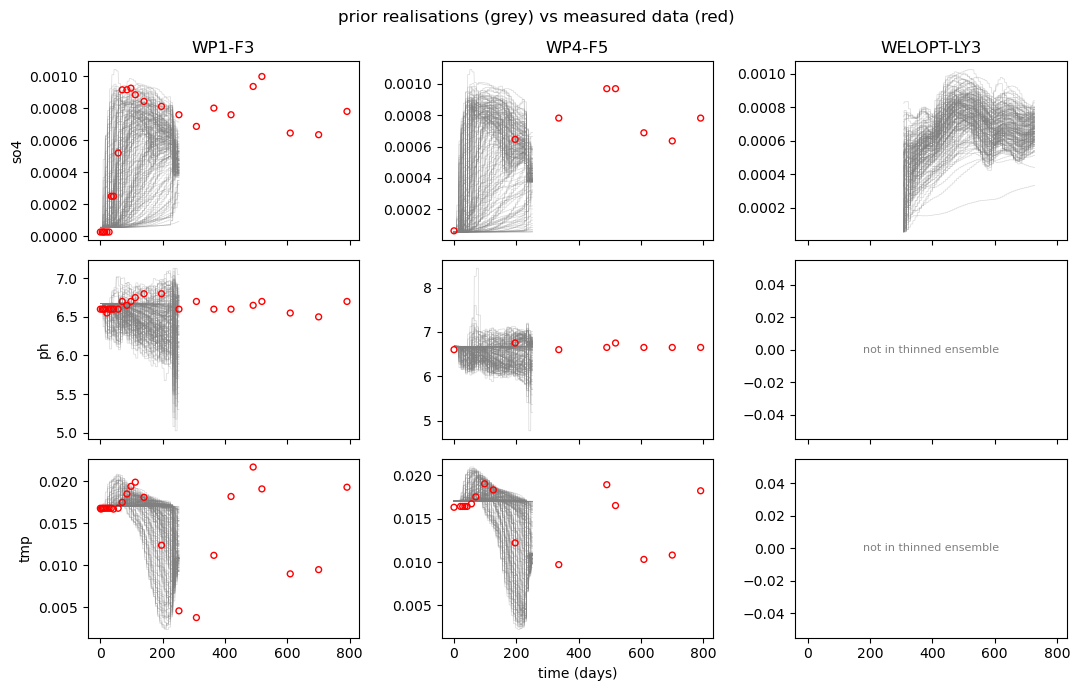

In [13]:
# measured data, written alongside the template by the obs & weights notebook
meas = pd.read_csv(t_d / "_obs.conc.simvsmeas.csv")
meas["variable"] = meas.variable.str.lower()
meas = meas[meas["meas"] <= 1e30]  # drop the no-data flag

obs_to_plot = ["wp1-f3", "wp4-f5", "welopt-ly3"]   # near site, far site, supply well (forecast)
vars_to_plot = ["so4", "ph", "tmp"]

# the prebaked ensemble is thinned, so a given full series may not be present in `oe`;
# plot only the observations that actually survived thinning
oe_cols = set(oe.columns)

fig, axes = plt.subplots(len(vars_to_plot), len(obs_to_plot),
                         figsize=(11, 7), sharex=True)
for row, var in enumerate(vars_to_plot):
    for col, oid in enumerate(obs_to_plot):
        ax = axes[row, col]
        sel = conc[(conc.obsid == oid) & (conc.variable == var)].sort_values("time")
        sel = sel[sel.obsnme.isin(oe_cols)]   # keep only obs present in the ensemble
        names = sel.obsnme.values
        tvals = sel.time.values
        if len(names):
            for r in oe.index:
                ax.plot(tvals, oe.loc[r, names].values, color="0.5", alpha=0.3, lw=0.5)
        else:
            ax.text(0.5, 0.5, "not in thinned ensemble",
                    ha="center", va="center", fontsize=8, color="0.5",
                    transform=ax.transAxes)
        m = meas[(meas.obsid == oid) & (meas.variable == var)]
        ax.scatter(m.time, m.meas, s=18, facecolor="none", edgecolor="r", zorder=10)
        if row == 0:
            ax.set_title(oid.upper())
        if col == 0:
            ax.set_ylabel(var)
axes[-1, 1].set_xlabel("time (days)")
fig.suptitle("prior realisations (grey) vs measured data (red)")
fig.tight_layout()
plt.show()

What we want to see is the red points sitting *inside* the grey envelope: the prior should be wide enough to contain observed behaviour. If it is, the model and prior are not obviously broken and we can trust them enough to keep going. We are not after a tight fit here — a wide prior is a feature, not a bug. Tightening it is the job of history matching, and only if the forecast actually needs it.

If measured points fell *outside* the spread, that would be the signal to stop and revisit the model structure, the prior bounds, or the data themselves before going any further.

## The prior forecast: do we even need to history match?

Now the decision question. The forecast is **peak SO₄ at the supply well during the supply period** (days 308–728). Treatment cost scales with concentration, so the quantity the operator actually designs to is the *upper tail* of this forecast — the P95 of peak SO₄ — not a single best guess.

The supply well is screened over three intervals (`welopt-ly1`, `welopt-ly3`, `welopt-ly5`). The forecast is the maximum over **all** of them and over all supply-period times: it is the worst the supplied water gets, wherever and whenever. (In this case the central screen `welopt-ly3` usually dominates, but we take the max over screens so the forecast cannot miss a peak on another screen.)

The model carries SO₄ in mol/L, so we convert to mg/L using the molar mass of sulfate (96.06 g/mol).

In [14]:
SO4_MOLAR_MASS = 96.06          # g/mol -> mg/L = mol/L * 96060
SUPPLY_START, SUPPLY_END = 308.0, 728.0          # the supply period (days)
SUPPLY_SCREENS = ["welopt-ly1", "welopt-ly3", "welopt-ly5"]  # all supply-well screens

# all supply-well SO4 observations, across every screen, within the supply period
fc = conc[(conc.obsid.isin(SUPPLY_SCREENS)) &
          (conc.variable == "so4") &
          (conc.time >= SUPPLY_START) &
          (conc.time <= SUPPLY_END)].copy()
fc_names = [n for n in fc.obsnme.values if n in oe.columns]

# peak SO4 per realisation = max over all screens AND all supply times, mol/L -> mg/L
peak_molL = oe.loc[:, fc_names].max(axis=1)
peak_mgL = peak_molL * SO4_MOLAR_MASS * 1e3
peak_mgL.describe()

count    195.000000
mean      82.213386
std        7.161580
min       57.597960
25%       77.990730
50%       81.937451
75%       86.875944
max       98.431721
dtype: float64

The prior forecast distribution is summarised by where its centre sits and how far its upper tail reaches — the median (a typical outcome) and the P95 (what the operator designs to):

In [15]:
# the 'base' realisation is the mean parameter set; exclude it from the summary
real_peaks = peak_mgL.drop(index="base", errors="ignore")
prior_median = real_peaks.median()
prior_p95 = real_peaks.quantile(0.95)
print(f"prior peak SO4 ({real_peaks.shape[0]} realisations):")
print(f"  median = {prior_median:.0f} mg/L")
print(f"  P95    = {prior_p95:.0f} mg/L   (the design target)")
print(f"  5-95%  = {real_peaks.quantile(0.05):.0f} - {real_peaks.quantile(0.95):.0f} mg/L")

prior peak SO4 (194 realisations):
  median = 82 mg/L
  P95    = 94 mg/L   (the design target)
  5-95%  = 72 - 94 mg/L


And the figure that makes the case — the prior forecast distribution, with the median and the P95 design target marked:

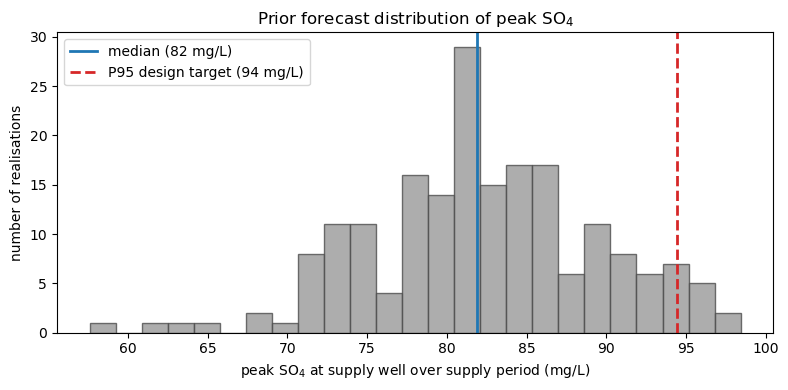

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_peaks, bins=25, color="0.6", edgecolor="0.3", alpha=0.8)
ax.axvline(prior_median, color="C0", lw=2, label=f"median ({prior_median:.0f} mg/L)")
ax.axvline(prior_p95, color="C3", lw=2, ls="--", label=f"P95 design target ({prior_p95:.0f} mg/L)")
ax.set_xlabel("peak SO$_4$ at supply well over supply period (mg/L)")
ax.set_ylabel("number of realisations")
ax.set_title("Prior forecast distribution of peak SO$_4$")
ax.legend()
fig.tight_layout()
plt.show()

### A risk lens on the same distribution

The distribution is the analysis; a *threshold* is just one way of reading it. Suppose your supply contract carried a 90 mg/L trigger — a clause that bites if peak SO₄ goes above it. The probability of tripping that trigger is simply the fraction of the same realisations that land above 90 mg/L:

In [17]:
TRIGGER_MGL = 90.0   # an illustrative contractual trigger
p_trigger = (real_peaks > TRIGGER_MGL).mean()
print(f"P(peak SO4 > {TRIGGER_MGL:.0f} mg/L | prior) = {p_trigger:.2f}")

# the EU drinking-water standard for sulfate is 250 mg/L - comfortably met here;
# cost, not compliance, is what drives this decision
print(f"(EU 250 mg/L standard: P(>250) = {(real_peaks > 250).mean():.2f} - comfortably met)")

P(peak SO4 > 90 mg/L | prior) = 0.15
(EU 250 mg/L standard: P(>250) = 0.00 - comfortably met)


A risk statement like *P(>90) ≈ 0.15* is a **lens on the same distribution, not a different analysis**: change the trigger and you slide the cut along the same histogram. The drinking-water standard (250 mg/L) is comfortably met under every plausible parameter set, so compliance is not the question — cost is, and cost tracks the whole distribution.

This distribution is the reason prior Monte Carlo is worth doing — and it already half-answers the title question.

- If the distribution were **narrow**, the forecast would be near-decided whatever the parameters: the operator could size treatment to a P95 they already trust, and history matching would buy almost nothing — history matching for nothing.
- If it is **wide**, the P95 is poorly pinned and the design target could swing by tens of mg/L. There is then a case for sharpening it with the history data — *if* those data are actually informative about this forecast, and *if* the model can assimilate them. That is the question the next notebooks answer.

Notice what we have **not** assumed: that conditioning only narrows. It can also shift the centre. The synthetic truth was deliberately drawn from the *upper quartile* of this prior distribution (see the [obs & weights notebook](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb)), so the prior median under-predicts the reality we will be scored against. If the data pull the forecast toward that truth, the posterior should move *up* as well as in — the value of data may be truer news, not just narrower news. We keep going to find out.

For one last look, here is the supply-well SO₄ time series across the whole simulation, at the central screen (`welopt-ly3`, the one that usually carries the peak). The grey spread is the prior; the shaded band marks the supply period where the forecast lives.

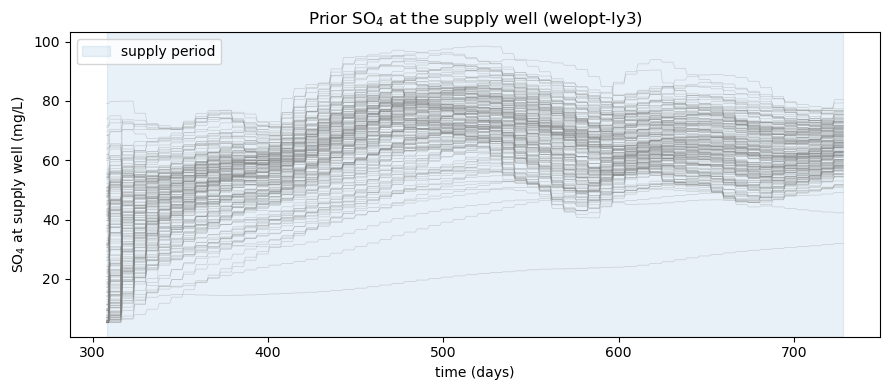

In [18]:
# the central screen usually carries the peak; plot its full series for context
TS_SCREEN = "welopt-ly3"
sw = conc[(conc.obsid == TS_SCREEN) & (conc.variable == "so4")].sort_values("time")
sw = sw[sw.obsnme.isin(set(oe.columns))]   # only obs present in the (possibly thinned) ensemble
sw_names = sw.obsnme.values
tvals = sw.time.values

fig, ax = plt.subplots(figsize=(9, 4))
for r in oe.index:
    ax.plot(tvals, oe.loc[r, sw_names].values * SO4_MOLAR_MASS * 1e3,
            color="0.5", alpha=0.3, lw=0.5)
ax.axvspan(SUPPLY_START, SUPPLY_END, color="C0", alpha=0.1, label="supply period")
ax.set_xlabel("time (days)")
ax.set_ylabel("SO$_4$ at supply well (mg/L)")
ax.set_title(f"Prior SO$_4$ at the supply well ({TS_SCREEN})")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Where we are

We have run the prior ensemble (a handful live, the full 201 loaded) and asked the decision question of the prior: peak SO₄ at the supply well sits around a typical value with a P95 design target some way above it, and the distribution is wide enough that the target is poorly pinned. There is a case for sharpening it with the history data — and an open question, planted above, of whether conditioning will narrow the forecast, shift it, or both.

The expensive part is now behind us: we have **one** prior ensemble of 201 model runs. Re-running it would cost ~20 CPU-hours. So instead of conditioning the full model directly, the next notebook trains a **DSI emulator** on this prior ensemble and does the conditioning on the emulator — in seconds rather than days.

Continue to [dsi basics](../part1_05_dsi_basics/dizon_dsi_basics.ipynb), where we build that emulator, check its fidelity against held-out realisations *before* trusting it, and then condition it to see what the history data do to this forecast.